## 1. Import the Required Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPool2D, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom, Rescaling
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

## 2. Data Preprocessing

In [18]:
train_dir = r"New-Cattle-Diseasee-3/train"
valid_dir = r"New-Cattle-Diseasee-3/valid"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [19]:
# Data augmentation pipeline
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.15),
], name="data_augmentation")

In [20]:
training_set = image_dataset_from_directory(
    directory=train_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, 
    shuffle=True,
    seed=42
)

validation_set = image_dataset_from_directory(
    directory=valid_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False, 
    seed=42
)

# Get class names before any transforms
class_names = training_set.class_names
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Found 2800 files belonging to 4 classes.
Found 598 files belonging to 4 classes.
Classes (4): ['fmd', 'healthy', 'lumpy skin', 'mastitis']


In [21]:
# Cache and prefetch for much faster training
AUTOTUNE = tf.data.AUTOTUNE

training_set = training_set.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_set = validation_set.cache().prefetch(buffer_size=AUTOTUNE)

## 3. Build Model with Transfer Learning (EfficientNetB0)

### Why switch from your custom CNN to EfficientNetB0?
- Your custom CNN had **17.9M parameters** trained from scratch on only **2,518 images** → massive overfitting
- EfficientNetB0 was **pretrained on ImageNet** (1.2M images) so it already knows edges, textures, shapes
- We freeze its weights initially and only train your 8-class head → much less overfitting
- EfficientNetB0 also handles its own normalization internally (no need for /255 rescaling)

In [22]:
# Transfer learning with EfficientNetB0
# Load pretrained base (weights from ImageNet, exclude top classification layer)
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze base model initially - fine-tune later
base_model.trainable = False

# Build the full model
inputs = tf.keras.Input(shape=(224, 224, 3))

# Apply augmentation only during training
x = data_augmentation(inputs)


x = base_model(x, training=False)

# GlobalAveragePooling
x = GlobalAveragePooling2D()(x)

# BatchNorm & Dropout before Dense layers
x = BatchNormalization()(x)
x = Dropout(0.4)(x)  # Regularization to combat overfitting

# Smaller Dense layer (512)- for less overfitting
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization_1 (Batc  (None, 1280)             5120      
 hNormalization)                                                 
                                                           

## 4. Phase 1 - Train the Head (Base Frozen)

In [23]:
# Add this BEFORE Phase 1 training cell
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for _, labels in training_set:
    train_labels.extend(np.argmax(labels.numpy(), axis=1))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


In [24]:
# Callbacks
callbacks = [
    # Stop training when val_loss stops improving (saves time + prevents overfitting)
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # Automatically reverts to best epoch!
        verbose=1
    ),
    # Save the best model checkpoint to disk
    ModelCheckpoint(
        'best_model.h5',         
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True, 
        verbose=1
    ),
    # Reduce learning rate when val_loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

In [25]:
# Phase 1: Train only the new head with frozen base
# Use a higher LR here since we're training from scratch
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 1: Training head with frozen base...")
history1 = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=15,  # EarlyStopping will stop this when ready
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Phase 1: Training head with frozen base...
Epoch 1/15
88/88 [==============================] - ETA: 0s - loss: 0.7947 - accuracy: 0.7661
Epoch 1: val_accuracy improved from -inf to 0.75585, saving model to best_model.h5
88/88 [==============================] - 136s 1s/step - loss: 0.7947 - accuracy: 0.7661 - val_loss: 0.6655 - val_accuracy: 0.7559 - lr: 0.0010
Epoch 2/15
88/88 [==============================] - ETA: 0s - loss: 0.4880 - accuracy: 0.8471
Epoch 2: val_accuracy improved from 0.75585 to 0.79599, saving model to best_model.h5
88/88 [==============================] - 123s 1s/step - loss: 0.4880 - accuracy: 0.8471 - val_loss: 0.5145 - val_accuracy: 0.7960 - lr: 0.0010
Epoch 3/15
88/88 [==============================] - ETA: 0s - loss: 0.3931 - accuracy: 0.8746
Epoch 3: val_accuracy did not improve from 0.79599
88/88 [==============================] - 188s 2s/step - loss: 0.3931 - accuracy: 0.8746 - val_loss: 0.6552 - val_accuracy: 0.7642 - lr: 0.0010
Epoch 4/15
88/88 [========

## 5. Phase 2 - Fine-Tuning (Unfreeze Top Layers)

In [26]:
# Unfreeze the top layers of the base model
# This adapts the pretrained features to specific cattle disease images
base_model.trainable = True

# Freeze all layers EXCEPT the last 30 (fine-tune only top portion)
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")


model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 100x lower than phase 1 -  to avoid destroying pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Phase 2: Fine-tuning top layers...")
history2 = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Trainable layers: 30 / 238
Phase 2: Fine-tuning top layers...
Epoch 1/20
88/88 [==============================] - ETA: 0s - loss: 0.3429 - accuracy: 0.8818
Epoch 1: val_accuracy improved from 0.83779 to 0.89632, saving model to best_model.h5
88/88 [==============================] - 193s 2s/step - loss: 0.3429 - accuracy: 0.8818 - val_loss: 0.3679 - val_accuracy: 0.8963 - lr: 1.0000e-05
Epoch 2/20
88/88 [==============================] - ETA: 0s - loss: 0.2858 - accuracy: 0.8968
Epoch 2: val_accuracy improved from 0.89632 to 0.90301, saving model to best_model.h5
88/88 [==============================] - 147s 2s/step - loss: 0.2858 - accuracy: 0.8968 - val_loss: 0.3453 - val_accuracy: 0.9030 - lr: 1.0000e-05
Epoch 3/20
88/88 [==============================] - ETA: 0s - loss: 0.2695 - accuracy: 0.9064
Epoch 3: val_accuracy did not improve from 0.90301
88/88 [==============================] - 133s 2s/step - loss: 0.2695 - accuracy: 0.9064 - val_loss: 0.3360 - val_accuracy: 0.9013 - lr: 1.0

## 6. Visualize Training Results

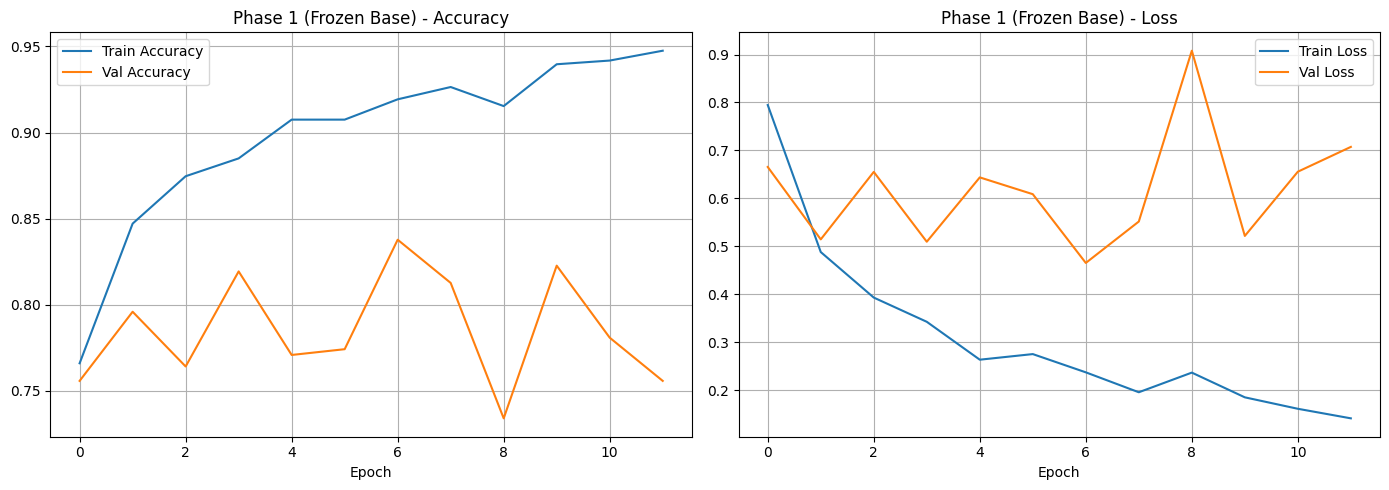

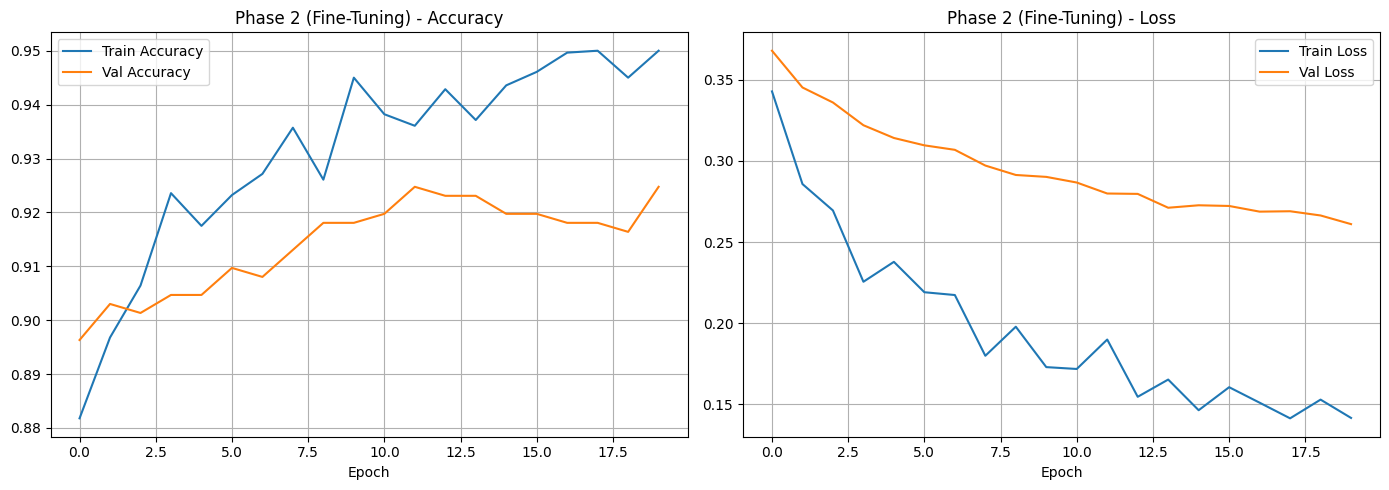

In [27]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history1, "Phase 1 (Frozen Base)")
plot_history(history2, "Phase 2 (Fine-Tuning)")

## 7. Evaluate Final Model

In [28]:
# Load the best saved weights back into the model
model.load_weights('best_model.h5')

# Evaluate
val_loss, val_acc = model.evaluate(validation_set)
print(f"\nBest Model - Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")

19/19 [==============================] - 16s 836ms/step - loss: 0.2799 - accuracy: 0.9247

Best Model - Val Loss: 0.2799 | Val Accuracy: 0.9247 (92.5%)


              precision    recall  f1-score   support

         fmd       0.90      0.90      0.90       100
     healthy       0.96      0.90      0.93       271
  lumpy skin       0.91      0.97      0.94       177
    mastitis       0.85      0.94      0.90        50

    accuracy                           0.92       598
   macro avg       0.91      0.93      0.92       598
weighted avg       0.93      0.92      0.92       598



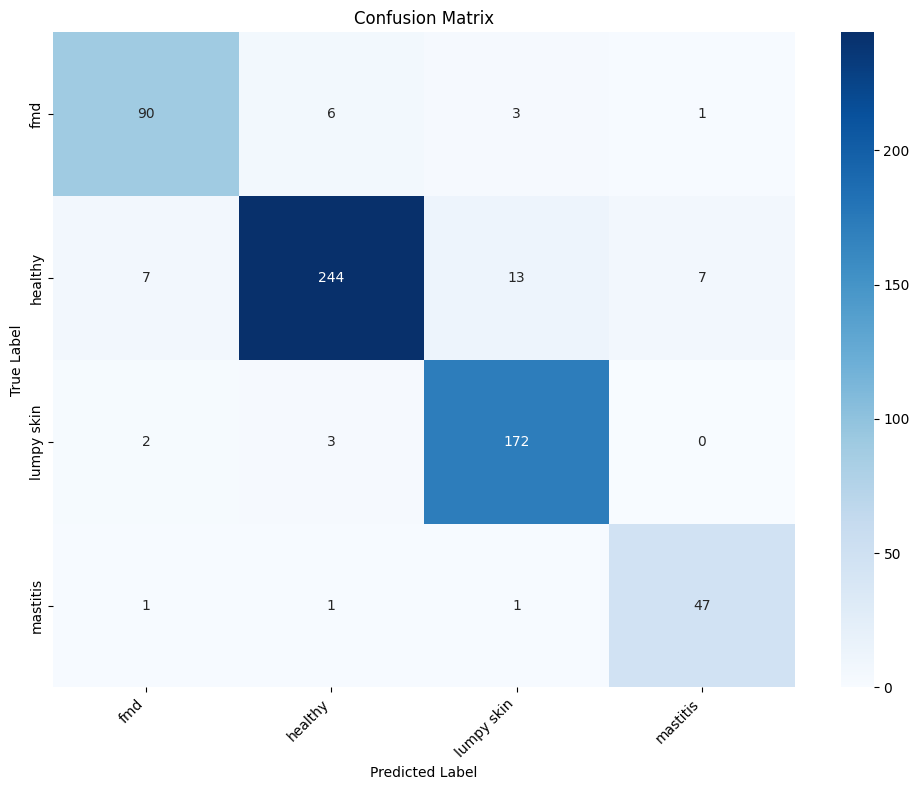

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for images, labels in validation_set:
    preds = model.predict(images, verbose=0)  # ← only change
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
# Ensure class weights are pure Python floats (not numpy/tensor types)
class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}